In [1]:
import pandas as pd

filepath_data_eval_str = '../../datasets/jppost/sts_chimei_pairs/sts_chimei_pairs.csv'

data_eval_df = pd.read_csv(filepath_data_eval_str)

chimei1_list = data_eval_df['chimei1'].tolist()
chimei2_list = data_eval_df['chimei2'].tolist()
labels_list = (data_eval_df['similarity'] / 5).tolist()

print(len(chimei1_list))
print(len(chimei2_list))
print(len(labels_list))

2478651
2478651
2478651


In [ ]:
from sentence_transformers import SentenceTransformer, models


modelpath_base_str = '../../fine-tuning/tuned_models/'

modeltype_str = 'multil'
# modeltype_str = 'sonoisa_20230403_044056'
# modeltype_str = 'tohoku-bb2'
# modeltype_str = 'tohoku-bbwwm_vocab-added'
# modeltype_str = 'izumi_lab_20230418_095436_jppost'

# modelpath_str = modelpath_base_str + modeltype_str
# modelpath_str = modelpath_base_str + "multil_jppost-cp-e1to3-b512/checkpoints/14526"
modelpath_str = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
# modelpath_str = "../../vocabulary_expansion/models_vocab_added/multil_vocab-added"

transformer = models.Transformer(modelpath_str)

pooling = models.Pooling(transformer.get_word_embedding_dimension(), pooling_mode='mean')
model = SentenceTransformer(modules=[transformer, pooling])

In [3]:
import datetime
import time
from sentence_transformers import util

print(datetime.datetime.now())
start_time = time.time()

embeddings1_list = model.encode(chimei1_list)
print("embeddings1 done", time.time() - start_time)
embeddings2_list = model.encode(chimei2_list)
print("embeddings2 done", time.time() - start_time)

cossims_list = list()
for (embedding1, embedding2) in zip(embeddings1_list, embeddings2_list):
    cossim_float = util.cos_sim(embedding1, embedding2)[0][0]
    cossims_list.append(cossim_float)


2023-05-07 10:16:22.488687
embeddings1 done 759.537047624588
embeddings2 done 1499.8591814041138


In [4]:
from scipy.stats import pearsonr, spearmanr

pearson_float, _ = pearsonr(labels_list, cossims_list)
spearman_float, _ = spearmanr(labels_list, cossims_list)

print(f'{pearson_float = }')
print(f'{spearman_float = }')

pearson_float = 0.15637048649257623
spearman_float = 0.2271929277866859


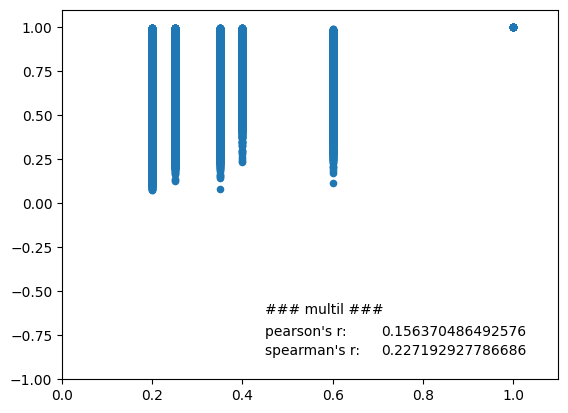

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# plt.style.use('dark_background')
plt.style.use('default')

filepath_to_save_str = 'results/scatter_' + modeltype_str + '.png'

plt.clf() # Clear the plot

# x_sr = pd.Series(labels_list).values
# y_sr = pd.Series(cossims_list).values
# cossim_snsplot = sns.jointplot(x=x_sr, y=y_sr, xlim=(0, 1), ylim=(-1, 1), color='#086972')

plt.xlim(0,1.1)
plt.ylim(-1,1.1)
plt.scatter(labels_list, cossims_list, s=20, c=None, marker='o')

plt.text(0.45, -0.63, f"### {modeltype_str} ###", horizontalalignment='left')
plt.text(0.45, -0.75, "pearson's r:", horizontalalignment='left')
plt.text(1.03, -0.75, '%.15f' % pearson_float, horizontalalignment='right')
plt.text(0.45, -0.86, "spearman's r:", horizontalalignment='left')
plt.text(1.03, -0.86, '%.15f' % spearman_float, horizontalalignment='right')

plt.savefig(filepath_to_save_str)
plt.show()